# Exploratory Data Analysis — Mutual Fund Analytics

## Capstone Project I — BlueStock Fintech

This notebook performs exploratory data analysis on mutual fund, NAV, AUM, SIP, investor, folio, and portfolio holdings data.

### Analysis Covered

1. NAV Trend Analysis
2. AUM Growth Analysis
3. Monthly SIP Inflow Analysis
4. Category Inflow Heatmap
5. Investor Demographics
6. Geographic Distribution
7. Folio Count Growth
8. NAV Return Correlation
9. Sector Allocation
10. Key EDA Findings

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
fund_master = pd.read_csv("01_fund_master.csv")
nav_history = pd.read_csv("02_nav_history.csv")
aum = pd.read_csv("03_aum_by_fund_house.csv")
sip = pd.read_csv("04_monthly_sip_inflows.csv")
category_inflows = pd.read_csv("05_category_inflows.csv")
folio = pd.read_csv("06_industry_folio_count.csv")
scheme_performance = pd.read_csv("07_scheme_performance.csv")
investor_transactions = pd.read_csv("08_investor_transactions.csv")
portfolio_holdings = pd.read_csv("09_portfolio_holdings.csv")
benchmark = pd.read_csv("10_benchmark_indices.csv")

print("All datasets loaded successfully!")

All datasets loaded successfully!


In [3]:
datasets = {
    "fund_master": fund_master,
    "nav_history": nav_history,
    "aum": aum,
    "sip": sip,
    "category_inflows": category_inflows,
    "folio": folio,
    "scheme_performance": scheme_performance,
    "investor_transactions": investor_transactions,
    "portfolio_holdings": portfolio_holdings,
    "benchmark": benchmark
}

for name, df in datasets.items():
    print(f"\n{'='*60}")
    print(name)
    print("Shape:", df.shape)
    print("Columns:", df.columns.tolist())


fund_master
Shape: (40, 15)
Columns: ['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio_pct', 'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager', 'risk_category', 'sebi_category_code']

nav_history
Shape: (46000, 3)
Columns: ['amfi_code', 'date', 'nav']

aum
Shape: (90, 5)
Columns: ['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes']

sip
Shape: (48, 6)
Columns: ['month', 'sip_inflow_crore', 'active_sip_accounts_crore', 'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct']

category_inflows
Shape: (144, 3)
Columns: ['month', 'category', 'net_inflow_crore']

folio
Shape: (21, 6)
Columns: ['month', 'total_folios_crore', 'equity_folios_crore', 'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore']

scheme_performance
Shape: (40, 19)
Columns: ['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'b

In [4]:
for name, df in datasets.items():
    print(f"{name}: {df.shape[0]:,} rows × {df.shape[1]} columns")

fund_master: 40 rows × 15 columns
nav_history: 46,000 rows × 3 columns
aum: 90 rows × 5 columns
sip: 48 rows × 6 columns
category_inflows: 144 rows × 3 columns
folio: 21 rows × 6 columns
scheme_performance: 40 rows × 19 columns
investor_transactions: 10,797 rows × 4 columns
portfolio_holdings: 322 rows × 8 columns
benchmark: 8,050 rows × 3 columns


In [5]:
# Convert date to datetime
nav_history["date"] = pd.to_datetime(nav_history["date"])

# Keep the analysis period 2022–2026
nav_eda = nav_history[
    (nav_history["date"] >= "2022-01-01") &
    (nav_history["date"] <= "2026-12-31")
].copy()

# Sort data
nav_eda = nav_eda.sort_values(["amfi_code", "date"])

print("NAV records:", len(nav_eda))
print("Number of schemes:", nav_eda["amfi_code"].nunique())
print("Date range:", nav_eda["date"].min(), "to", nav_eda["date"].max())

NAV records: 46000
Number of schemes: 40
Date range: 2022-01-03 00:00:00 to 2026-05-29 00:00:00


In [6]:
fig = px.line(
    nav_eda,
    x="date",
    y="nav",
    color="amfi_code",
    title="NAV Trends of 40 Mutual Fund Schemes (2022–2026)",
    labels={
        "date": "Date",
        "nav": "NAV",
        "amfi_code": "Fund"
    }
)

fig.update_layout(
    height=700,
    hovermode="x unified"
)

fig.show()

In [7]:
fig = px.line(
    nav_eda,
    x="date",
    y="nav",
    color="amfi_code",
    title="NAV Trends with 2023 Bull Run and 2024 Market Correction",
    labels={
        "date": "Date",
        "nav": "NAV",
        "amfi_code": "Fund"
    }
)

# Highlight 2023 bull-run period
fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    fillcolor="green",
    opacity=0.08,
    line_width=0,
    annotation_text="2023 Bull Run",
    annotation_position="top left"
)

# Highlight 2024 correction period
fig.add_vrect(
    x0="2024-01-01",
    x1="2024-12-31",
    fillcolor="red",
    opacity=0.08,
    line_width=0,
    annotation_text="2024 Market Correction",
    annotation_position="top left"
)

fig.update_layout(
    height=700,
    hovermode="x unified"
)

fig.show()

In [9]:
print(aum.head())
print("\nColumns:")
print(aum.columns.tolist())
print("\nData types:")
print(aum.dtypes)

         date           fund_house  aum_lakh_crore  aum_crore  num_schemes
0  2022-03-31      SBI Mutual Fund            6.05     605000          186
1  2022-03-31  ICICI Prudential MF            4.65     465000          216
2  2022-03-31     HDFC Mutual Fund            4.35     435000          195
3  2022-03-31      Nippon India MF            2.70     270000          177
4  2022-03-31    Kotak Mahindra MF            2.70     270000          168

Columns:
['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes']

Data types:
date               object
fund_house         object
aum_lakh_crore    float64
aum_crore           int64
num_schemes         int64
dtype: object


In [10]:
# Convert date to datetime
aum["date"] = pd.to_datetime(aum["date"])

# Extract year
aum["year"] = aum["date"].dt.year

# Keep 2022–2025
aum_eda = aum[
    aum["year"].between(2022, 2025)
].copy()

print("Years:", sorted(aum_eda["year"].unique()))
print("Fund houses:", aum_eda["fund_house"].nunique())

display(aum_eda.head())

Years: [np.int32(2022), np.int32(2023), np.int32(2024), np.int32(2025)]
Fund houses: 10


,date,fund_house,aum_lakh_crore,aum_crore,num_schemes,year
0,2022-03-31,SBI Mutual Fund,6.05,605000,186,2022
1,2022-03-31,ICICI Prudential MF,4.65,465000,216,2022
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195,2022
3,2022-03-31,Nippon India MF,2.70,270000,177,2022
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168,2022


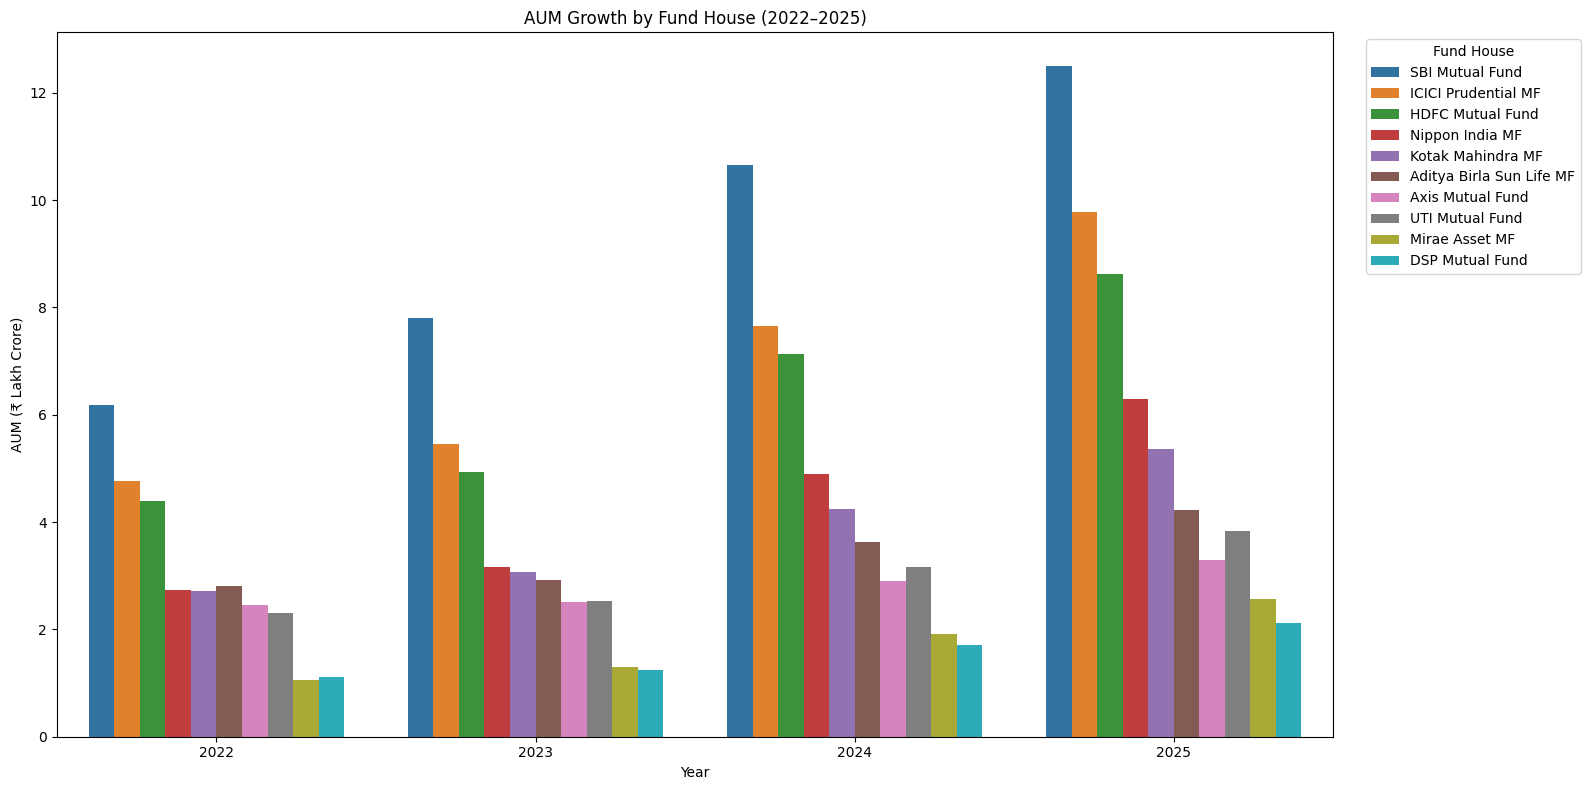

In [11]:
plt.figure(figsize=(16, 8))

sns.barplot(
    data=aum_eda,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house",
    errorbar=None
)

plt.title("AUM Growth by Fund House (2022–2025)")
plt.xlabel("Year")
plt.ylabel("AUM (₹ Lakh Crore)")
plt.legend(
    title="Fund House",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

### AUM Growth by Fund House

The grouped bar chart compares assets under management across major fund houses from 2022 to 2025. SBI Mutual Fund remains one of the largest fund houses by AUM, with its scale clearly visible relative to other fund houses.

In [12]:
print(sip.head())
print("\nColumns:")
print(sip.columns.tolist())
print("\nData types:")
print(sip.dtypes)

     month  sip_inflow_crore  active_sip_accounts_crore  \
0  2022-01             11517                       4.91   
1  2022-02             11438                       4.93   
2  2022-03             12328                       5.09   
3  2022-04             11863                       5.48   
4  2022-05             12286                       5.55   

   new_sip_accounts_lakh  sip_aum_lakh_crore  yoy_growth_pct  
0                   9.10                4.80             NaN  
1                   8.20                4.85             NaN  
2                  10.50                5.01             NaN  
3                   9.52                5.12             NaN  
4                   8.10                5.15             NaN  

Columns:
['month', 'sip_inflow_crore', 'active_sip_accounts_crore', 'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct']

Data types:
month                         object
sip_inflow_crore               int64
active_sip_accounts_crore    float64
new_sip_a

In [13]:
# Convert month to datetime
sip["month"] = pd.to_datetime(sip["month"])

# Keep Jan 2022 to Dec 2025
sip_eda = sip[
    (sip["month"] >= "2022-01-01") &
    (sip["month"] <= "2025-12-31")
].copy()

sip_eda = sip_eda.sort_values("month")

print("Date range:", sip_eda["month"].min(), "to", sip_eda["month"].max())
print("Number of months:", len(sip_eda))
print("Highest SIP inflow:", sip_eda["sip_inflow_crore"].max())

display(sip_eda.tail())

Date range: 2022-01-01 00:00:00 to 2025-12-01 00:00:00
Number of months: 48
Highest SIP inflow: 31002


,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
43,2025-08-01,28265,8.85,9.80,15.18,20.04
44,2025-09-01,29361,9.00,10.50,15.38,19.80
45,2025-10-01,29529,9.10,9.45,15.55,16.61
46,2025-11-01,30200,9.20,9.10,15.72,19.27
47,2025-12-01,31002,9.35,9.80,15.90,17.17


In [14]:
dec_2025 = sip_eda[
    sip_eda["month"] == "2025-12-01"
]

display(dec_2025)

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
47,2025-12-01,31002,9.35,9.8,15.9,17.17


In [15]:
fig = px.line(
    sip_eda,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflows — January 2022 to December 2025",
    labels={
        "month": "Month",
        "sip_inflow_crore": "SIP Inflow (₹ Crore)"
    },
    markers=True
)

# Find December 2025 value
dec_value = dec_2025["sip_inflow_crore"].iloc[0]

fig.add_annotation(
    x="2025-12-01",
    y=dec_value,
    text=f"₹{dec_value:,} Cr — Dec 2025",
    showarrow=True,
    arrowhead=2,
    ax=-80,
    ay=-60
)

fig.update_layout(
    height=600,
    hovermode="x unified"
)

fig.show()

### SIP Inflow Trend

Monthly SIP inflows increased substantially between 2022 and 2025, reflecting growing participation in systematic investment plans. The series reached its highest recorded level in December 2025, at ₹31,002 crore.

In [16]:
print(category_inflows.head())

print("\nColumns:")
print(category_inflows.columns.tolist())

print("\nData types:")
print(category_inflows.dtypes)

     month         category  net_inflow_crore
0  2024-04        Large Cap            2413.0
1  2024-04          Mid Cap            3897.0
2  2024-04        Small Cap            3533.0
3  2024-04        Flexi Cap            4947.0
4  2024-04  Large & Mid Cap            4214.0

Columns:
['month', 'category', 'net_inflow_crore']

Data types:
month                object
category             object
net_inflow_crore    float64
dtype: object


In [17]:
category_inflows["month"] = pd.to_datetime(category_inflows["month"])

category_eda = category_inflows.sort_values("month").copy()

print("Date range:", category_eda["month"].min(), "to", category_eda["month"].max())
print("Categories:", category_eda["category"].unique())
print("Number of records:", len(category_eda))

Date range: 2024-04-01 00:00:00 to 2025-03-01 00:00:00
Categories: ['Large Cap' 'Hybrid' 'Gilt' 'Short Duration' 'Sectoral/Thematic'
 'Value/Contra' 'Liquid' 'Large & Mid Cap' 'Flexi Cap' 'Small Cap'
 'Mid Cap' 'ELSS']
Number of records: 144


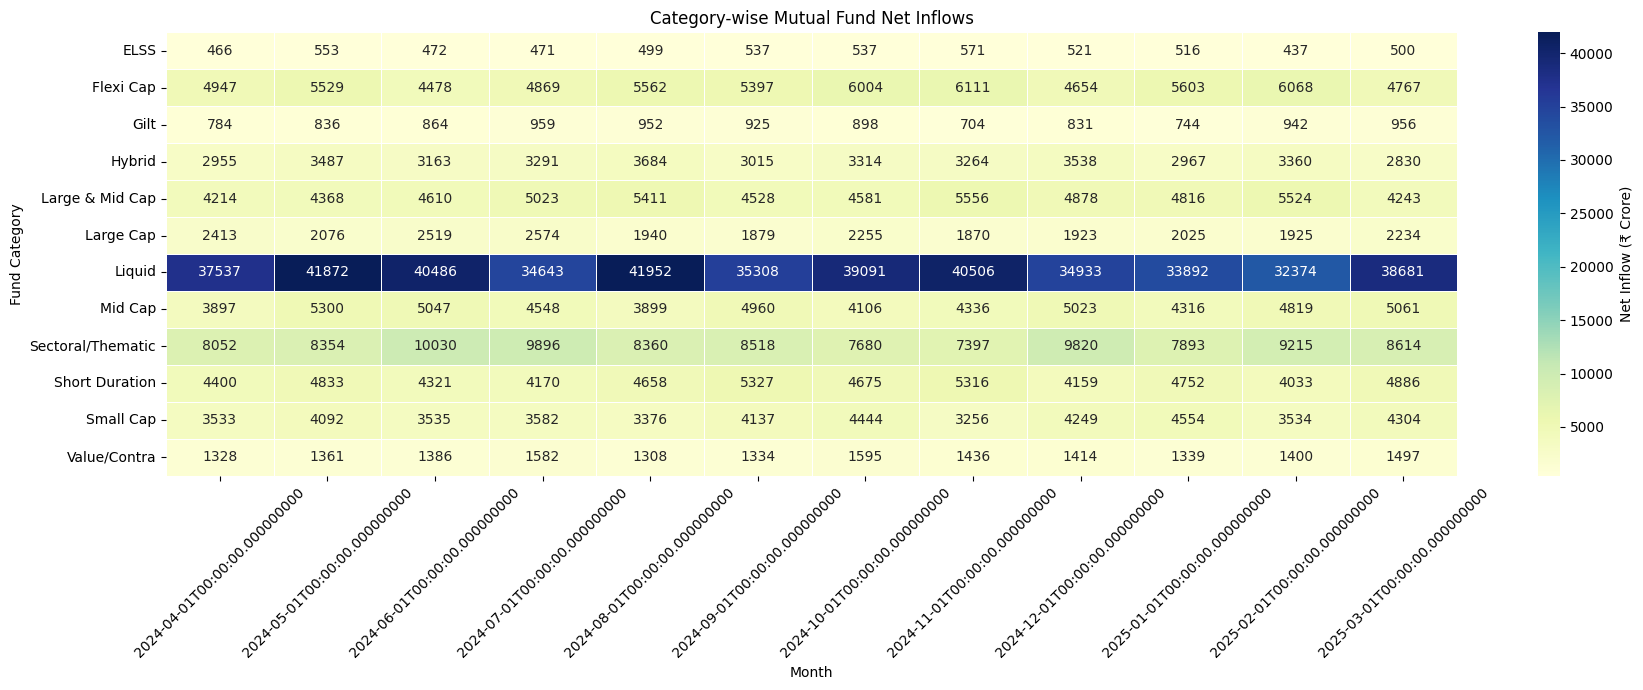

In [18]:
category_pivot = category_eda.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

plt.figure(figsize=(18, 7))

sns.heatmap(
    category_pivot,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu",
    linewidths=0.5,
    cbar_kws={"label": "Net Inflow (₹ Crore)"}
)

plt.title("Category-wise Mutual Fund Net Inflows")
plt.xlabel("Month")
plt.ylabel("Fund Category")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Category-wise Inflow Analysis

The heatmap shows how net mutual fund inflows varied across different fund categories over the observed period. Higher-intensity cells indicate months with stronger net inflows, while lighter cells represent comparatively lower inflows.

In [22]:
investor_transactions = pd.read_csv(
    "08_investor_transactions.csv",
    index_col=False
)

print(investor_transactions.head())
print("\nColumns:")
print(investor_transactions.columns.tolist())

  investor_id transaction_date  amfi_code transaction_type  amount_inr  \
0   INV003054       2024-01-01     119092              SIP        1834   
1   INV002952       2024-01-01     148567       Redemption      392882   
2   INV003420       2024-01-01     118636              SIP         912   
3   INV003436       2024-01-01     118634              SIP        1102   
4   INV004691       2024-01-01     119094          Lumpsum        8682   

         state       city city_tier age_group  gender  annual_income_lakh  \
0    Telangana  Hyderabad       T30       56+  Female                77.1   
1       Punjab   Amritsar       B30     18-25    Male                 7.1   
2      Haryana  Faridabad       B30     36-45    Male                47.2   
3  Maharashtra     Mumbai       T30     36-45  Female                54.4   
4        Delhi      Noida       T30     26-35    Male                14.5   

  payment_mode kyc_status  
0          UPI   Verified  
1       Cheque   Verified  
2      M

In [23]:
investor_eda = investor_transactions.copy()

print("Age groups:")
print(investor_eda["age_group"].value_counts().sort_index())

print("\nGender:")
print(investor_eda["gender"].value_counts())

print("\nTransaction types:")
print(investor_eda["transaction_type"].value_counts())

Age groups:
age_group
18-25     4916
26-35    13463
36-45     8146
46-55     3779
56+       2474
Name: count, dtype: int64

Gender:
gender
Male      21809
Female    10969
Name: count, dtype: int64

Transaction types:
transaction_type
SIP           19716
Lumpsum        8095
Redemption     4967
Name: count, dtype: int64


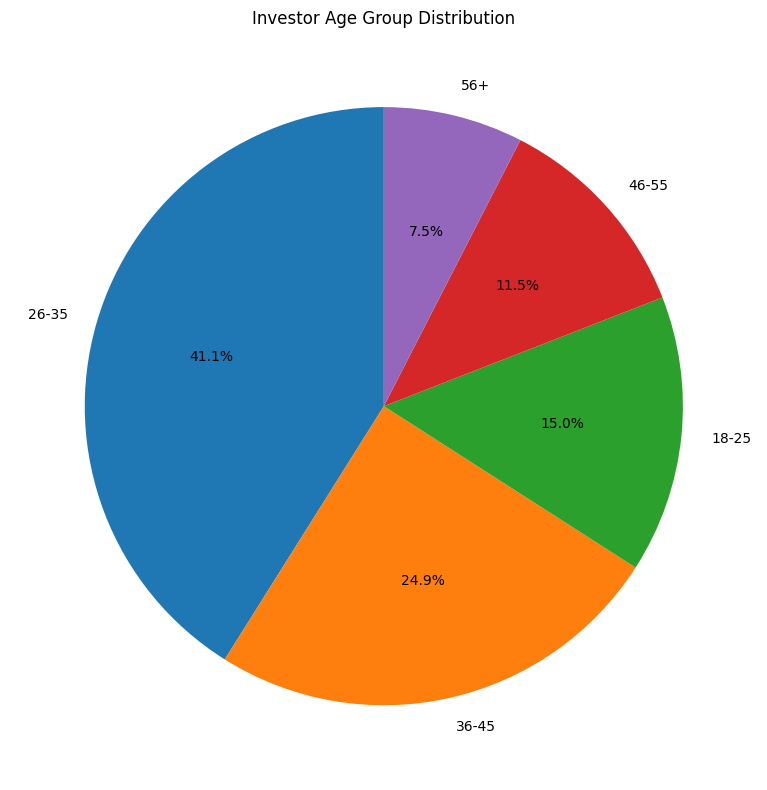

In [24]:
age_counts = investor_eda["age_group"].value_counts()

plt.figure(figsize=(8, 8))

plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Investor Age Group Distribution")
plt.tight_layout()
plt.show()


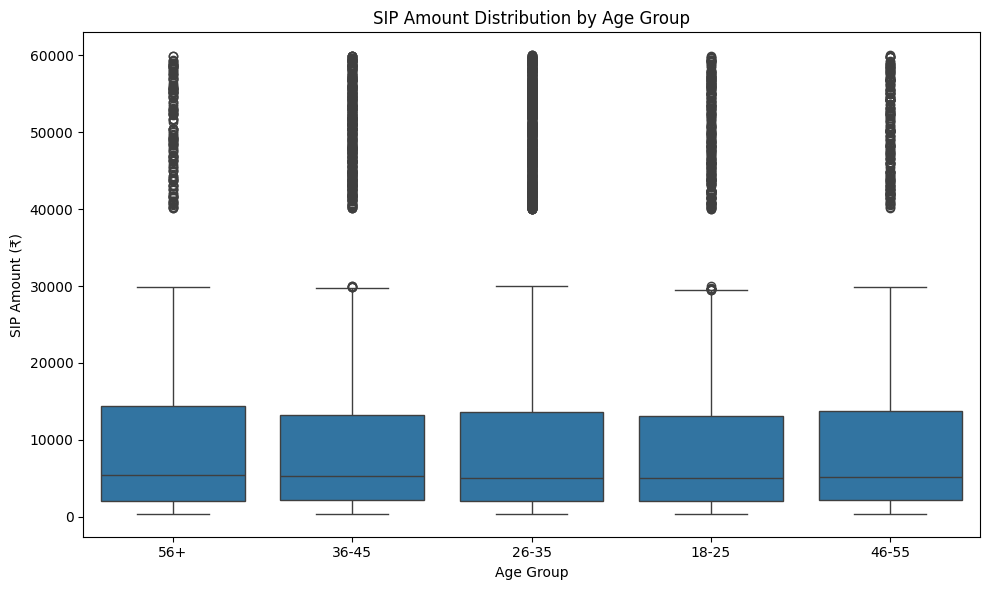

In [25]:
sip_transactions = investor_eda[
    investor_eda["transaction_type"] == "SIP"
].copy()

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=sip_transactions,
    x="age_group",
    y="amount_inr"
)

plt.title("SIP Amount Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("SIP Amount (₹)")
plt.tight_layout()
plt.show()

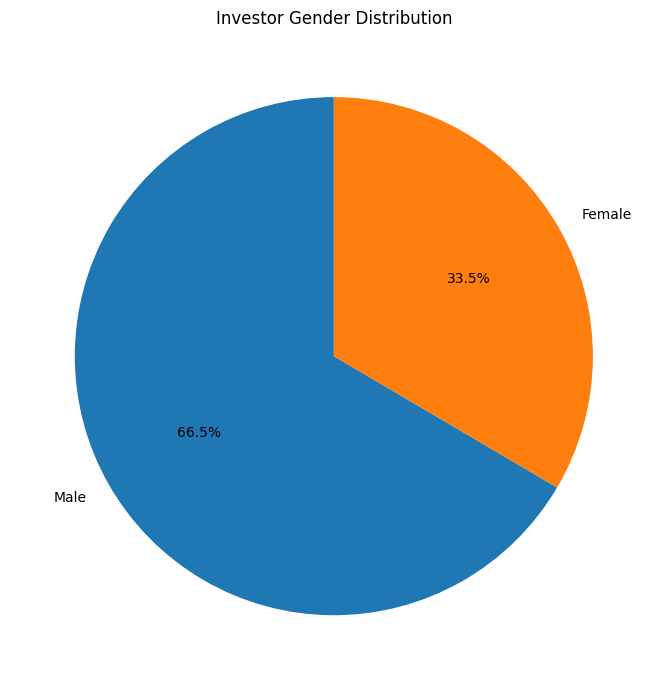

In [26]:
gender_counts = investor_eda["gender"].value_counts()

plt.figure(figsize=(7, 7))

plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Investor Gender Distribution")
plt.tight_layout()
plt.show()

### Investor Demographics

The age distribution shows that investors in the dataset are concentrated mainly in the 26–35 and 36–45 age groups. The SIP amount box plot shows variation in investment sizes across age groups, while the gender distribution indicates a higher representation of male investors in the transaction data.

In [29]:
print("States:", investor_eda["state"].nunique())
print("\nTop states by number of transactions:")
print(investor_eda["state"].value_counts().head(10))

print("\nCity tiers:")
print(investor_eda["city_tier"].value_counts())

States: 12

Top states by number of transactions:
state
Punjab            2965
Madhya Pradesh    2931
Tamil Nadu        2806
Gujarat           2780
West Bengal       2748
Haryana           2736
Telangana         2718
Uttar Pradesh     2695
Delhi             2677
Karnataka         2621
Name: count, dtype: int64

City tiers:
city_tier
T30    21719
B30    11059
Name: count, dtype: int64


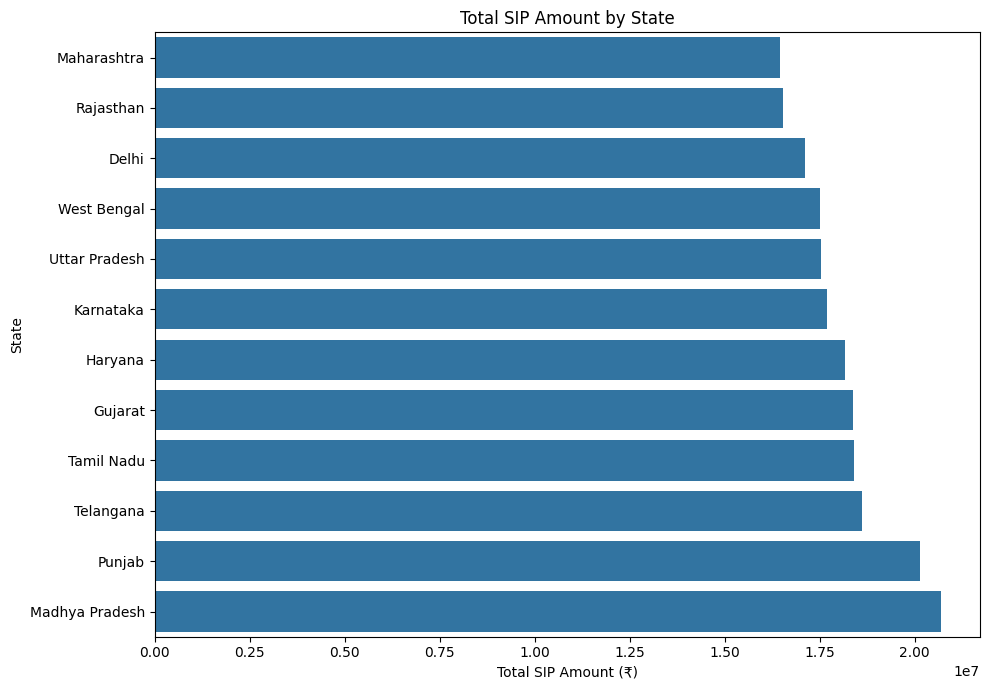

In [30]:
state_sip = (
    investor_eda[investor_eda["transaction_type"] == "SIP"]
    .groupby("state", as_index=False)["amount_inr"]
    .sum()
    .sort_values("amount_inr", ascending=True)
)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=state_sip,
    x="amount_inr",
    y="state",
    errorbar=None
)

plt.title("Total SIP Amount by State")
plt.xlabel("Total SIP Amount (₹)")
plt.ylabel("State")
plt.tight_layout()
plt.show()

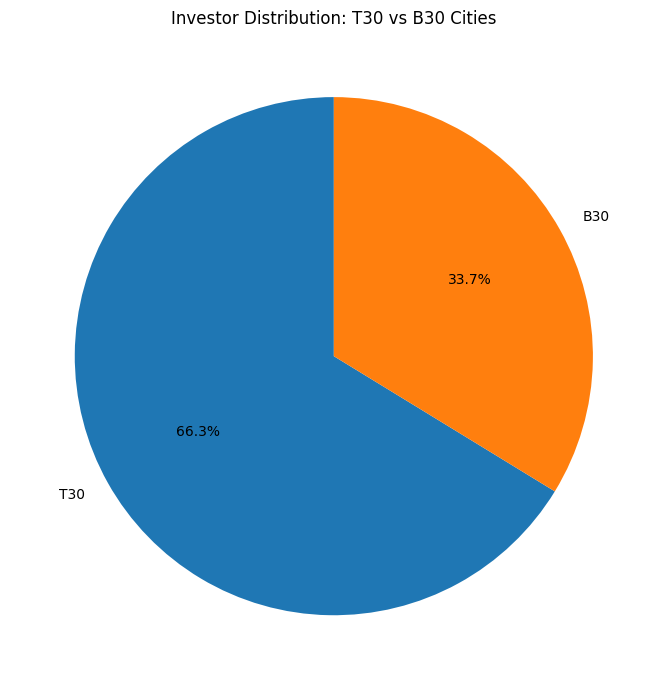

In [31]:
tier_counts = investor_eda["city_tier"].value_counts()

plt.figure(figsize=(7, 7))

plt.pie(
    tier_counts,
    labels=tier_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Investor Distribution: T30 vs B30 Cities")
plt.tight_layout()
plt.show()

### Geographic Distribution

The state-wise SIP chart highlights differences in total SIP investment across states, while the city-tier distribution shows that T30 cities account for a larger share of transactions than B30 cities in the dataset.

In [32]:
print(folio.head())

print("\nColumns:")
print(folio.columns.tolist())

print("\nData types:")
print(folio.dtypes)

     month  total_folios_crore  equity_folios_crore  debt_folios_crore  \
0  2022-01               13.26                 9.28               1.86   
1  2022-04               13.91                 9.74               1.95   
2  2022-07               13.85                 9.69               1.94   
3  2022-10               14.12                 9.88               1.98   
4  2023-01               14.81                10.37               2.07   

   hybrid_folios_crore  others_folios_crore  
0                 0.80                 1.33  
1                 0.83                 1.39  
2                 0.83                 1.38  
3                 0.85                 1.41  
4                 0.89                 1.48  

Columns:
['month', 'total_folios_crore', 'equity_folios_crore', 'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore']

Data types:
month                   object
total_folios_crore     float64
equity_folios_crore    float64
debt_folios_crore      float64
hybrid_fol

In [33]:
folio["month"] = pd.to_datetime(folio["month"])

folio_eda = folio[
    (folio["month"] >= "2022-01-01") &
    (folio["month"] <= "2025-12-31")
].copy()

folio_eda = folio_eda.sort_values("month")

print("Date range:", folio_eda["month"].min(), "to", folio_eda["month"].max())
print("Number of observations:", len(folio_eda))

print("\nFirst observation:")
display(folio_eda.iloc[[0]])

print("\nLast observation:")
display(folio_eda.iloc[[-1]])

Date range: 2022-01-01 00:00:00 to 2025-12-01 00:00:00
Number of observations: 21

First observation:


,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01-01,13.26,9.28,1.86,0.8,1.33



Last observation:


,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
20,2025-12-01,26.12,18.28,3.66,1.57,2.61


In [34]:
fig = px.line(
    folio_eda,
    x="month",
    y="total_folios_crore",
    markers=True,
    title="Growth in Mutual Fund Folio Count (2022–2025)",
    labels={
        "month": "Month",
        "total_folios_crore": "Total Folios (₹ Crore)"
    }
)

# Mark starting value
fig.add_annotation(
    x="2022-01-01",
    y=13.26,
    text="13.26 Cr — Jan 2022",
    showarrow=True,
    arrowhead=2,
    ax=60,
    ay=40
)

# Mark ending value
fig.add_annotation(
    x="2025-12-01",
    y=26.12,
    text="26.12 Cr — Dec 2025",
    showarrow=True,
    arrowhead=2,
    ax=-80,
    ay=-50
)

fig.update_layout(
    height=600,
    hovermode="x unified"
)

fig.show()

### Folio Count Growth

The total mutual fund folio count increased from 13.26 crore in January 2022 to 26.12 crore in December 2025, indicating substantial growth in investor participation over the period.

In [35]:
print(nav_history.head())

print("\nColumns:")
print(nav_history.columns.tolist())

print("\nNumber of schemes:")
print(nav_history["amfi_code"].nunique())

   amfi_code       date      nav
0     119551 2022-01-03  54.3856
1     119551 2022-01-04  54.3474
2     119551 2022-01-05  54.6869
3     119551 2022-01-06  55.4550
4     119551 2022-01-07  55.3692

Columns:
['amfi_code', 'date', 'nav']

Number of schemes:
40


In [36]:
nav_corr = nav_history.copy()

nav_corr["date"] = pd.to_datetime(nav_corr["date"])

nav_corr = nav_corr.sort_values(
    ["amfi_code", "date"]
)

nav_corr["daily_return"] = (
    nav_corr.groupby("amfi_code")["nav"].pct_change()
)

print("Schemes:", nav_corr["amfi_code"].nunique())
print("Daily return missing values:", nav_corr["daily_return"].isna().sum())

Schemes: 40
Daily return missing values: 40


In [37]:
selected_funds = sorted(
    nav_corr["amfi_code"].unique()
)[:10]

print("Selected funds:")
print(selected_funds)

Selected funds:
[np.int64(100016), np.int64(100025), np.int64(100033), np.int64(101206), np.int64(101207), np.int64(101208), np.int64(102885), np.int64(102886), np.int64(102887), np.int64(118632)]


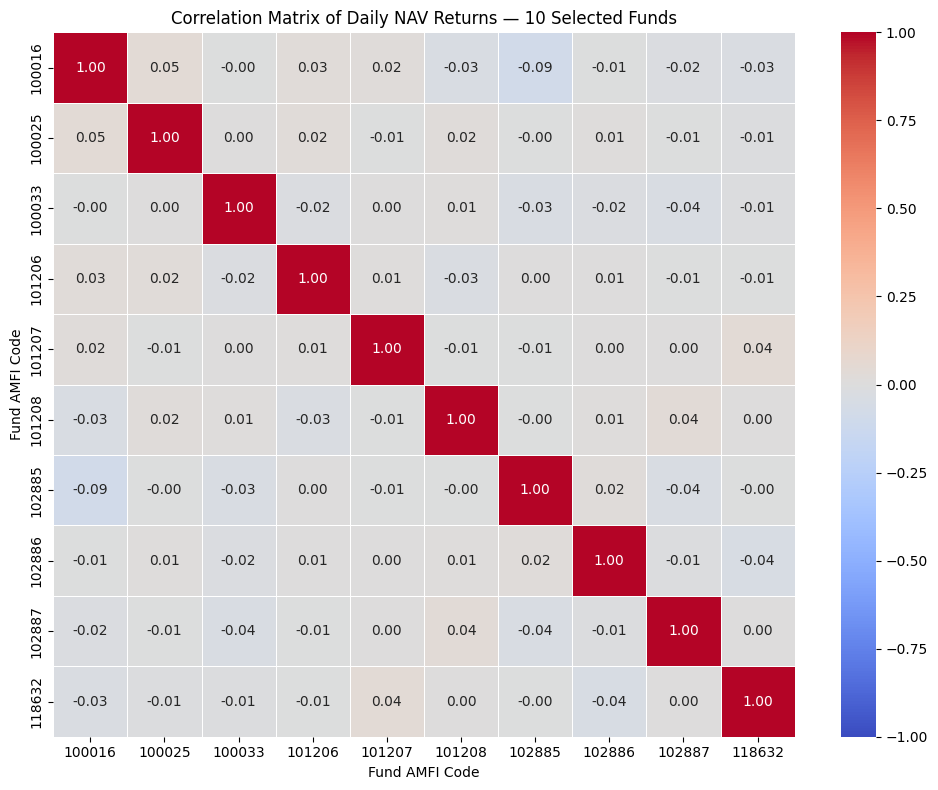

In [38]:
corr_data = nav_corr[
    nav_corr["amfi_code"].isin(selected_funds)
].pivot(
    index="date",
    columns="amfi_code",
    values="daily_return"
)

correlation_matrix = corr_data.corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5
)

plt.title("Correlation Matrix of Daily NAV Returns — 10 Selected Funds")
plt.xlabel("Fund AMFI Code")
plt.ylabel("Fund AMFI Code")
plt.tight_layout()
plt.show()

### NAV Return Correlation Analysis

The correlation matrix shows the degree to which daily returns of the selected mutual fund schemes move together. Higher positive correlations indicate similar return movements, while lower correlations indicate greater diversification potential.

In [39]:
print(portfolio_holdings.head())

print("\nColumns:")
print(portfolio_holdings.columns.tolist())

print("\nData types:")
print(portfolio_holdings.dtypes)

   amfi_code stock_symbol                stock_name       sector  weight_pct  \
0     119551    POWERGRID    Power Grid Corporation    Utilities       13.85   
1     119551     HDFCBANK             HDFC Bank Ltd      Banking       11.19   
2     119551       GRASIM     Grasim Industries Ltd  Diversified        9.90   
3     119551      DRREDDY  Dr. Reddy's Laboratories       Pharma        4.76   
4     119551   ASIANPAINT          Asian Paints Ltd       Paints       10.25   

   market_value_cr  current_price_inr portfolio_date  
0           737.09            6011.08     2025-12-31  
1            88.97            1074.65     2025-12-31  
2           208.45            5964.59     2025-12-31  
3           161.32            3748.82     2025-12-31  
4           725.90            1321.45     2025-12-31  

Columns:
['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']

Data types:
amfi_code              int64
stock_symbo

In [40]:
sector_allocation = (
    portfolio_holdings
    .groupby("sector", as_index=False)["weight_pct"]
    .sum()
    .sort_values("weight_pct", ascending=False)
)

print("Number of sectors:", len(sector_allocation))
display(sector_allocation)

Number of sectors: 14


,sector,weight_pct
1,Banking,652.26
7,IT,455.47
11,Pharma,407.45
0,Automobile,323.65
13,Utilities,265.54
6,FMCG,229.11
8,Infrastructure,192.16
4,Diversified,169.23
12,Telecom,145.62
3,Consumer Goods,127.61


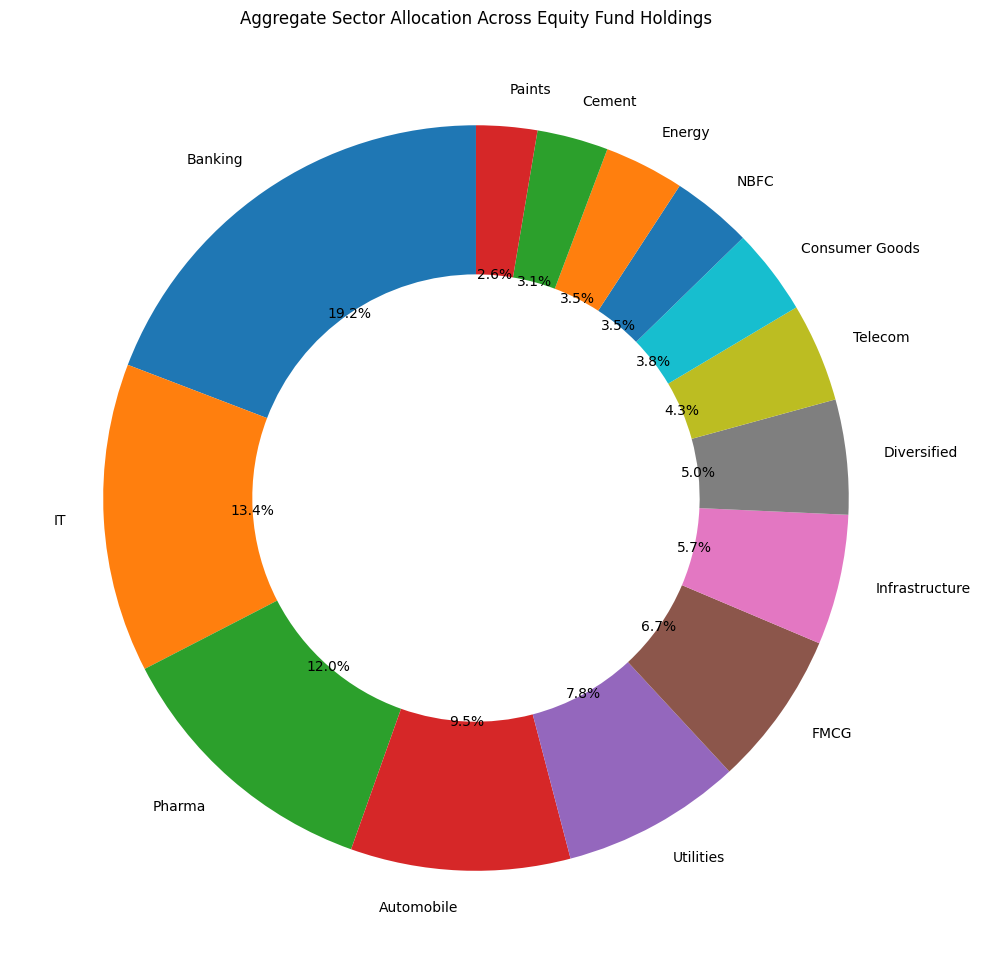

In [41]:
plt.figure(figsize=(10, 10))

plt.pie(
    sector_allocation["weight_pct"],
    labels=sector_allocation["sector"],
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops=dict(width=0.4)
)

plt.title("Aggregate Sector Allocation Across Equity Fund Holdings")
plt.tight_layout()
plt.show()

### Sector Allocation

The aggregate sector allocation shows that Banking, IT, and Pharma have the largest representation among the available equity fund holdings, while sectors such as Paints, Cement, and Energy have comparatively smaller aggregate weights.

# Key EDA Findings

### 1. NAV Trends
NAV levels across the 40 mutual fund schemes show different growth patterns over 2022–2026, with the analysis highlighting the 2023 growth period and the 2024 correction period.

**Chart reference:** NAV Trends of 40 Mutual Fund Schemes (2022–2026)

### 2. AUM Growth
AUM varied substantially across fund houses between 2022 and 2025, with SBI Mutual Fund maintaining a strong position among the major fund houses.

**Chart reference:** AUM Growth by Fund House (2022–2025)

### 3. SIP Inflows
Monthly SIP inflows increased considerably over the 2022–2025 period and reached their highest recorded level in December 2025.

**Chart reference:** Monthly SIP Inflows — January 2022 to December 2025

### 4. Category-wise Inflows
Net inflows differed considerably across fund categories and months, with the heatmap highlighting periods of relatively stronger and weaker category-level inflows.

**Chart reference:** Category-wise Mutual Fund Net Inflows

### 5. Investor Age Distribution
The 26–35 age group represents the largest share of transactions in the investor dataset, followed by the 36–45 age group.

**Chart reference:** Investor Age Group Distribution

### 6. SIP Amount by Age
SIP investment amounts vary across age groups, with the box plot showing differences in median values, spread, and outliers.

**Chart reference:** SIP Amount Distribution by Age Group

### 7. Geographic Distribution
SIP investment amounts differ across states, while T30 cities account for a larger share of transactions than B30 cities in the dataset.

**Chart reference:** Total SIP Amount by State and Investor Distribution: T30 vs B30 Cities

### 8. Folio Growth
Total mutual fund folios increased from 13.26 crore in January 2022 to 26.12 crore in December 2025, indicating substantial growth in investor participation.

**Chart reference:** Growth in Mutual Fund Folio Count (2022–2025)

### 9. Return Correlation
The correlation matrix shows that selected mutual fund schemes have varying degrees of correlation in their daily returns, providing insight into potential diversification opportunities.

**Chart reference:** Correlation Matrix of Daily NAV Returns — 10 Selected Funds

### 10. Sector Allocation
Banking, IT, and Pharma have the largest aggregate representation among the available equity fund holdings, while several other sectors have comparatively smaller aggregate weights.

**Chart reference:** Aggregate Sector Allocation Across Equity Fund Holdings

In [42]:
fig = px.line(
    sip_eda,
    x="month",
    y="active_sip_accounts_crore",
    title="Growth in Active SIP Accounts (2022–2025)",
    labels={
        "month": "Month",
        "active_sip_accounts_crore": "Active SIP Accounts (Crore)"
    },
    markers=True
)

fig.update_layout(
    height=600,
    hovermode="x unified"
)

fig.show()

In [43]:
fig = px.line(
    sip_eda,
    x="month",
    y="sip_aum_lakh_crore",
    title="Growth in SIP Assets Under Management (2022–2025)",
    labels={
        "month": "Month",
        "sip_aum_lakh_crore": "SIP AUM (₹ Lakh Crore)"
    },
    markers=True
)

fig.update_layout(
    height=600,
    hovermode="x unified"
)

fig.show()

In [44]:
fig = px.bar(
    sip_eda,
    x="month",
    y="new_sip_accounts_lakh",
    title="Monthly New SIP Accounts (2022–2025)",
    labels={
        "month": "Month",
        "new_sip_accounts_lakh": "New SIP Accounts (Lakh)"
    }
)

fig.update_layout(
    height=600,
    hovermode="x unified"
)

fig.show()

In [45]:
print("EDA analysis completed.")
print("Total charts created: 16")

EDA analysis completed.
Total charts created: 16
